**７　企業財務データと教師なし学習：主成分分析の事例**

　本節の例では、教師なし学習手法のひとつ、主成分分析を用いて、2章の15種類の企業財務指標を5つに次元削減します。そしてこれらの5つの主成分が、因子負荷量から何を意味するのかを定義した上で、どの企業がいかなる財務上の特徴を持つのかを評価します。本例では、東京証券取引所に上場する、非金融一般事業会社3,725社の15種類の財務指標を用いて、主成分分析を行い、企業評価手法の事例を示します。

　この実装を始めるに際し、統計分析と数値計算のためのpandasとnumpy、グラフ作成のためのmatplotlib、そして主成分分析のためのsklearnに含まれるPCAの４つのライブラリをインポートします。

In [2]:
#[1]ライブラリ読み込み
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

　続いて東京証券取引所に上場する非金融一般事業会社3,725社の15種類の財務指標を読み込みます。データはオンラインストレージのGithubから読み込みます。オンラインストレージから読み込んだ財務データは、セル[2]の2行目において、pandasデータフレームの配列に整形します。このデータの最左列は各社の証券コードです。セル[2]の3行目は、この証券コードをインデックス化しています。


In [ ]:
#[2]企業財務データ(CSVファイル)の読み込み
url = "https://github.com/nagamamo/data/blob/main/7_financial_data_PCA.csv?raw=true"#Git-hubからCSVデータの入手
data = pd.read_csv(url)#データフレームの作成
df = data.set_index("id")#証券コードをインデックスへ変更
df2 = df.dropna()
df2.head()

次にデータフレームdf2の企業財務データを標準化します。15種類の財務指標は、それぞれ単位が百分率であったり、解釈が倍数であることなど、様々です。それゆえここでは、15財務指標すべてのデータの標準偏差を1.0へ標準化して、横並びで比較可能なデータへ変換します。

In [ ]:
#[3]標準化
df2= df2.iloc[:, :].apply(lambda x: (x-x.mean())/x.std(), axis=0)
df2.head()
df2.describe()

　標準化された企業財務データdf2を用い、主成分を抽出して、各企業ごとに主成分得点を計算します。主成分得点とは、主成分分析により得られた主成分Xiに、個々の企業の財務データを代入して求める、第i主成分の数値です。主成分がi種類抽出されると、主成分得点もi種類算出されます。この主成分得点は、値が大きいほど、その第i主成分の特徴が大きい企業であることを意味します。本例では計算結果はscoreと名付けるデータフレームに格納されています。

In [ ]:
#[4]主成分分析の実行
from numpy.core.fromnumeric import searchsorted
pca = PCA()
pca.fit(df2)
score= pca.transform(df2)
score=pd.DataFrame(score,columns=["PC{}".format(x + 1) for x in range(len(df2.columns))])
score.set_index(df2.index,inplace=True)
score

　算出された3,725社×16種類の主成分得点はセル[5]のように記述することで、CSVファイルとして、データを書き出すことができます。

In [ ]:
#[5]標本企業別主成分得点の書き出し
from google.colab import files
score.to_csv('score.csv')
files.download('score.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

　抽出されたi種類の主成分が、それぞれどの程度の原データを反映しているかを確認するため、寄与率および累積寄与率を算出します。累積寄与率の結果を見ると、第1～5主成分までで全データの約70％を説明できていることがわかります。

In [ ]:
#[6]寄与率の算出
pd.DataFrame(pca.explained_variance_ratio_, index=["PC{}".format(x + 1) for x in range(len(df2.columns))])

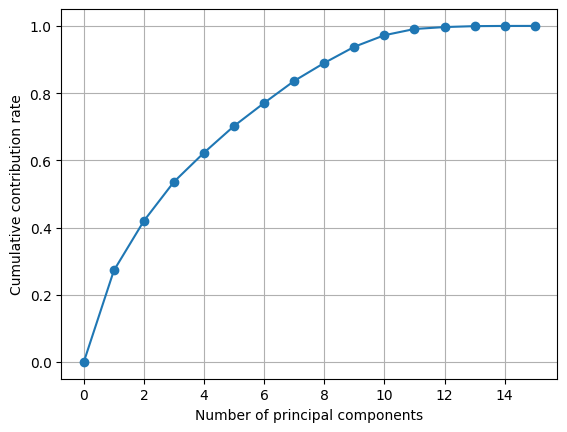

In [12]:
#[7]累積寄与率の算出
import matplotlib.ticker as ticker
plt.gca().get_xaxis().set_major_locator(ticker.MaxNLocator(integer=True))
plt.plot([0] + list( np.cumsum(pca.explained_variance_ratio_)), "-o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative contribution rate")
plt.grid()
plt.show()

最後に因子負荷量を算出して、それぞれの「主成分」が①収益性、②安全性、③成長性、④その他、のどれを意味しているのかを確認します。

In [ ]:
#[8]]因子負荷量の算出
pd.DataFrame(pca.components_, columns=df2.columns, index=["PC{}".format(x + 1) for x in range(len(df2.columns))])